In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
%matplotlib inline

**Phase 1** — Setup & First Look (10 min)
1.     Load housing.csv into a pandas DataFrame.
2.     Check the shape, .info(), and .describe() of the data.
3.     Look at the first and last few rows with .head() and .tail().
4.     Write 2–3 sentences: What do you notice? What questions does the data raise?


In [4]:
df = pd.read_csv('/content/housing.csv')
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.shape

(20640, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df.tail(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


after first look we can see there are 20640 rows and 10 columns in the dataset. The `ocean_proximity` column is a categorical feature.  Additionally, some columns like `total_rooms` and `population` need to check  outliers.

**Phase 2** — Exploratory Data Analysis (EDA)
This is detective work.looking for patterns, outliers, and relationships before touch any model.


---


1.     Plot histograms for every numeric column — look at housing_median_age, median_income, and median_house_value especially.
2.     Plot a geographic scatter plot of longitude vs. latitude, colored by median_house_value. (Hint: this will look like a map of California!)
3.     Compute a correlation matrix — which features correlate most strongly with median_house_value?
4.     Explore ocean_proximity with a bar chart or box plot against house value.
5.     Write a short 'EDA Findings' markdown section summarizing 3–5 insights.


<Figure size 1000x600 with 0 Axes>

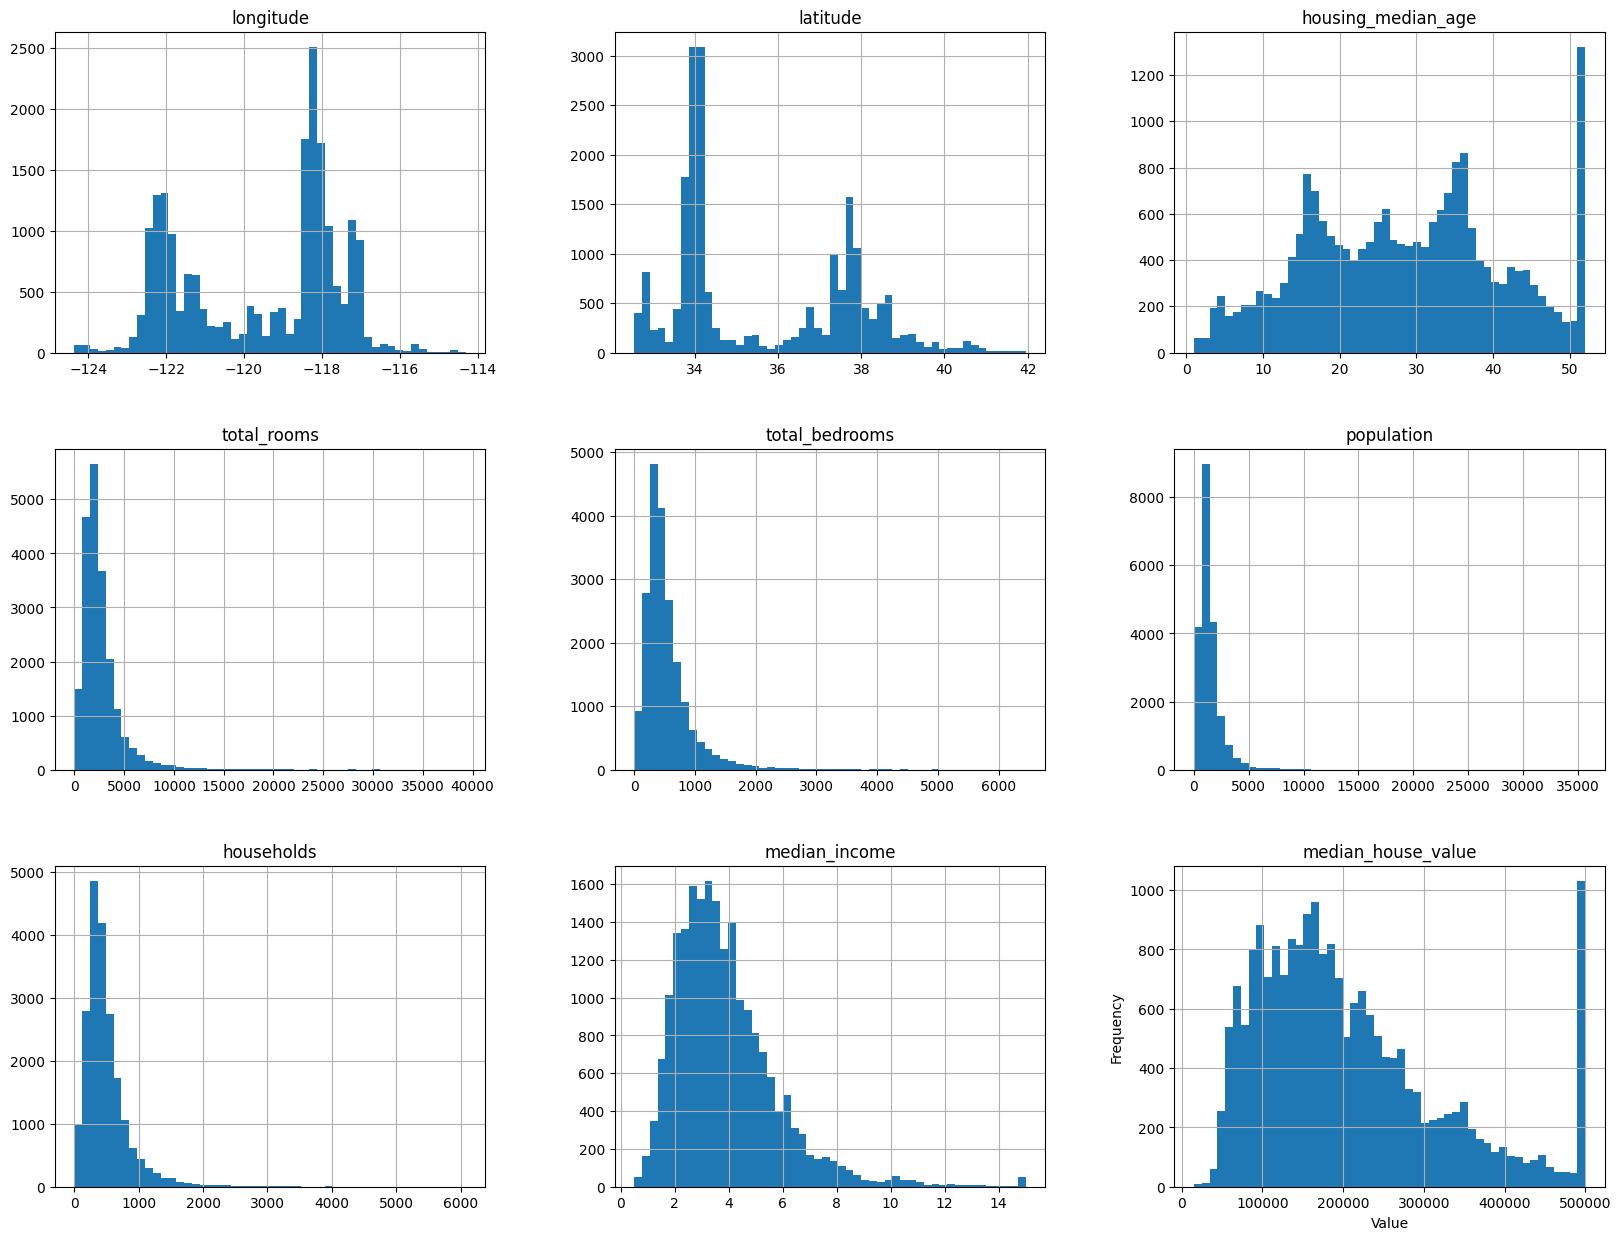

In [9]:
plt.figure(figsize=(10, 6))
df.hist(bins=50, figsize=(20, 15))
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

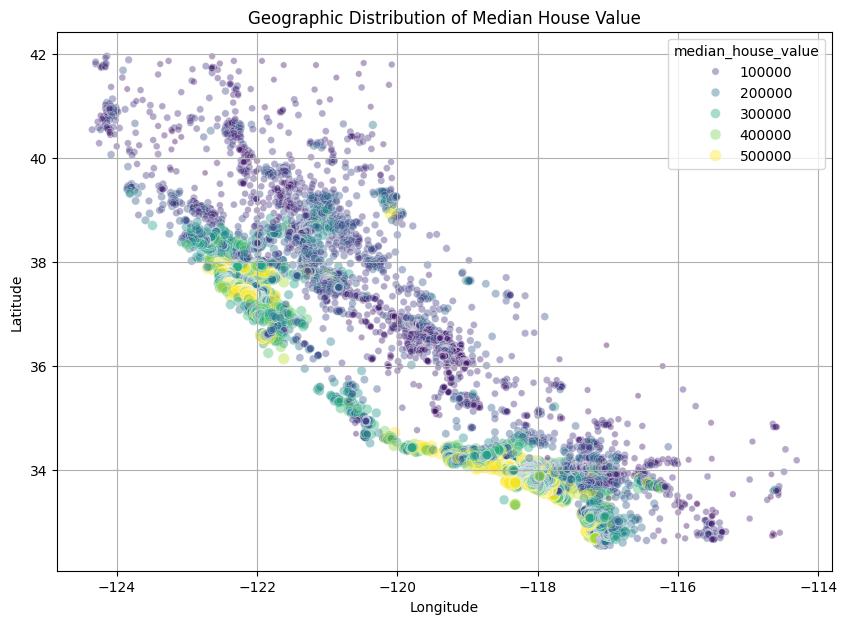

In [10]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='longitude', y='latitude', hue='median_house_value',
                size='median_house_value', alpha=0.4, palette='viridis', data=df)
plt.title('Geographic Distribution of Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

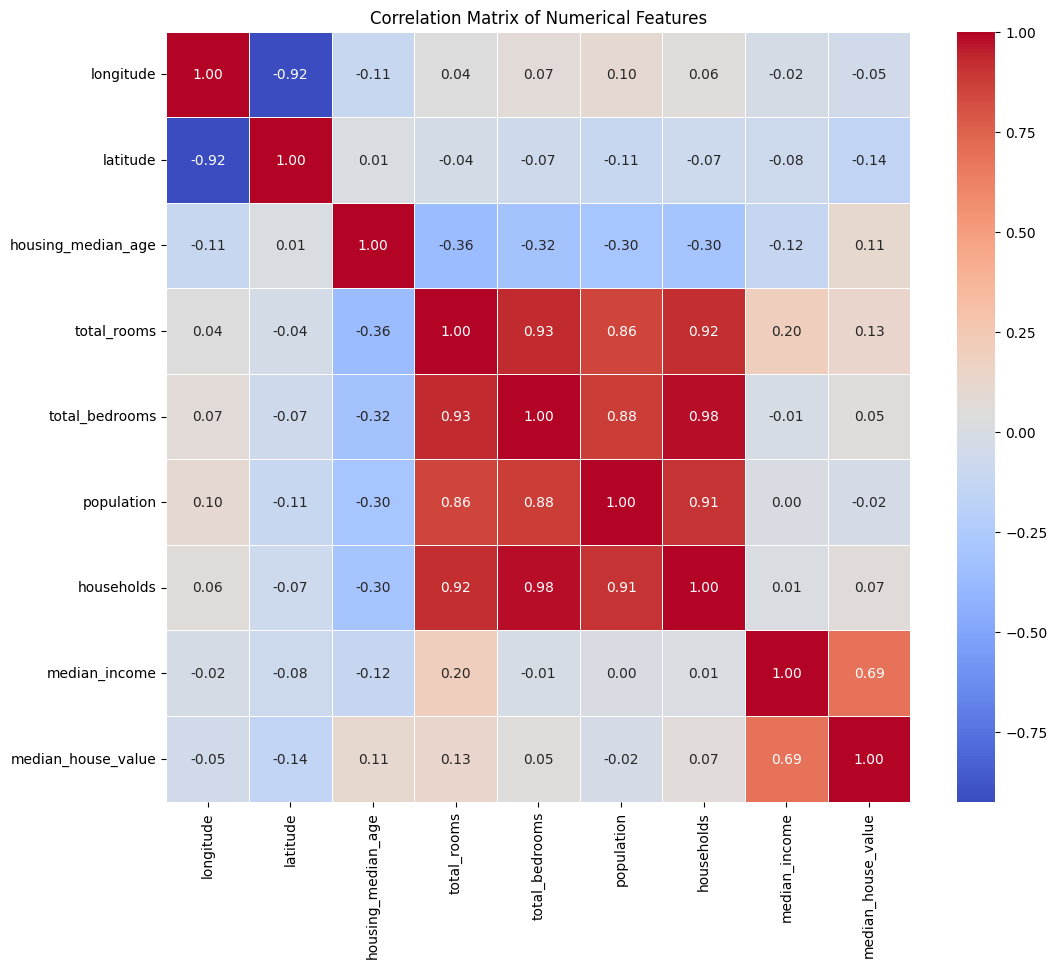

In [11]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [12]:
# Show correlations with median_house_value
print("Correlation with median_house_value:")
print(correlation_matrix['median_house_value'].sort_values(ascending=False))

Correlation with median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


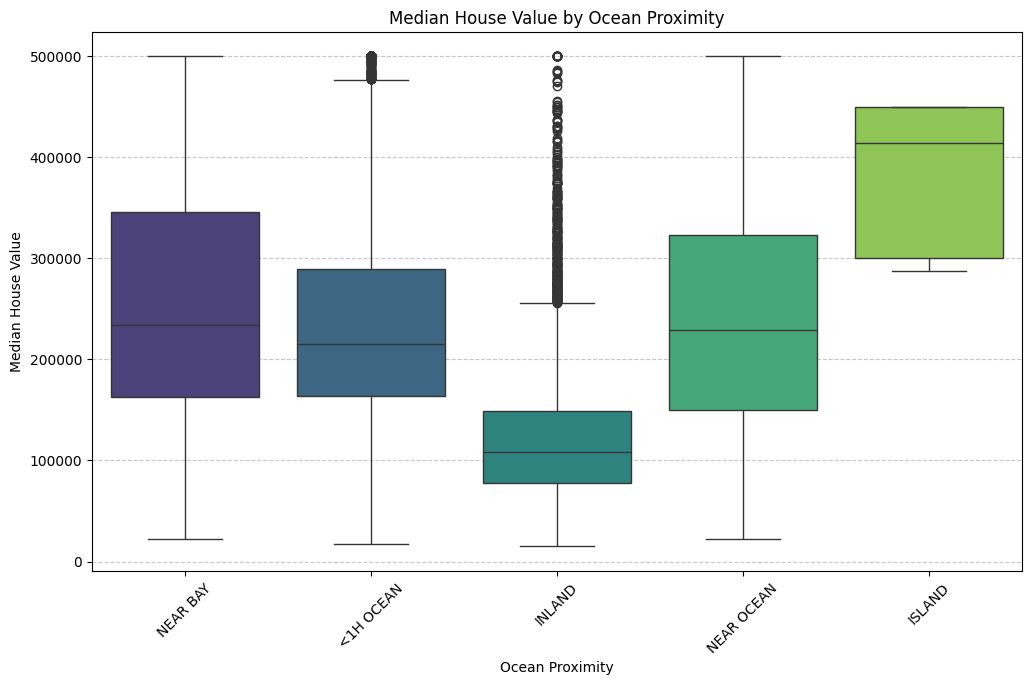

In [13]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, palette='viridis', hue='ocean_proximity', legend=False)
plt.title('Median House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## EDA Findings

Based on the initial data exploration, here are some key insights:

1.  **Missing Values:** The `total_bedrooms` column has approximately 207 missing values (out of 20640 entries), which will need to be handled during data preprocessing.
2.  **Strongest Predictor:** `median_income` exhibits a strong positive correlation (0.688) with `median_house_value`, indicating that areas with higher median incomes tend to have higher house values.
3.  **Geographic Influence:** The scatter plot of `longitude` vs. `latitude` colored by `median_house_value` clearly shows geographical patterns, with higher house values concentrated along the coast and in specific urban clusters.
4.  **Ocean Proximity Impact:** The box plot of `median_house_value` against `ocean_proximity` reveals that properties in `NEAR BAY`, `<1H OCEAN`, and `NEAR OCEAN` categories command significantly higher prices compared to `INLAND` properties. `ISLAND` properties also show high values, although this category might have a smaller sample size.
5.  **Skewed Distributions:** Several numerical features, such as `median_income` and `median_house_value`, appear to have skewed distributions (as observed from histograms), suggesting that transformations might be beneficial for modeling.

**Phase 3** — Data Cleaning & Preprocessing
A model is only as good as the data you feed it — garbage in, garbage out.
1.     Handle missing values in total_bedrooms (e.g., fill with median, or drop rows — justify your choice in markdown).
2.     Encode ocean_proximity into numbers (e.g., one-hot encoding with pd.get_dummies).
3.     (Optional but recommended) Engineer new features, e.g., rooms_per_household, bedrooms_per_room, population_per_household.
4.     Split data into training and test sets (e.g., 80/20 split) using train_test_split.
5.     Scale/normalize numeric features if your chosen models benefit from it


Handling Missing Values in `total_bedrooms`

In [21]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

# Verify that there are no more missing values in 'total_bedrooms'
print(f"Missing values in 'total_bedrooms' after imputation: {df['total_bedrooms'].isnull().sum()}")

Missing values in 'total_bedrooms' after imputation: 0


Encoding Categorical Feature: `ocean_proximity`


In [15]:
# Perform one-hot encoding on 'ocean_proximity'
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

# Display the first few rows with the new encoded columns
print("DataFrame after one-hot encoding 'ocean_proximity':")
print(df.head())

DataFrame after one-hot encoding 'ocean_proximity':
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                      False    

Feature Engineering

In [16]:
# Engineer new features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Display the first few rows with the new engineered features
print("DataFrame after engineering new features:")
display(df.head())

DataFrame after engineering new features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,6.281853,0.172096,2.181467


Splitting Data into Training and Test Sets


In [17]:
# Define features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Split data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 16)
X_test shape: (4128, 16)
y_train shape: (16512,)
y_test shape: (4128,)


### Scaling Numeric Features


In [22]:
# Identify numerical columns to scale
# Exclude one-hot encoded 'ocean_proximity' columns and any boolean columns if they exist
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

# Convert scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)


X_train[numerical_cols] = X_train_scaled
X_test[numerical_cols] = X_test_scaled

print("X_train after scaling numeric features:")
display(X_train.head())

print("X_test after scaling numeric features:")
display(X_test.head())

X_train after scaling numeric features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
14196,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,False,False,False,False,True,-0.174916,-0.211785,0.051376
8267,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,False,False,False,False,True,-0.402835,0.342185,-0.117362
17445,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,False,False,False,False,True,0.088216,-0.661658,-0.032280
14265,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,False,False,False,False,True,-0.600015,0.783032,0.077507
2271,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,False,True,False,False,False,0.349007,-0.550364,-0.068832


X_test after scaling numeric features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
20046,0.285347,0.195100,-0.286324,-0.522862,-0.247012,-0.030301,-0.370087,-1.155085,False,True,False,False,False,-0.520686,1.313568,0.067408
3024,0.060975,-0.235491,0.110435,0.138415,-0.247012,0.121851,0.220532,-0.708659,False,True,False,False,False,-0.165815,-1.121668,-0.036030
15663,-1.424870,1.009478,1.856173,0.546310,-0.247012,-0.102419,1.215396,-0.210402,False,False,False,True,False,-0.610765,-1.711928,-0.149989
20484,0.429943,-0.637999,-0.921138,0.188080,-0.247012,0.244979,-0.013091,0.975113,True,False,False,False,False,0.305115,-1.211888,0.030011
9814,-1.170581,0.457199,0.427842,-0.133821,-0.247012,-0.319653,-0.188964,-0.081794,False,False,False,False,True,0.024193,-0.479886,-0.052971


**Phase 4** — Model Training
Train at least two of the following regression models and compare them:
1.      Linear Regression — the simple, interpretable baseline.


1. Linear Regression Model


In [19]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 50888.66
Mean Squared Error (MSE): 5280716470.09
Root Mean Squared Error (RMSE): 72668.54
R-squared (R2): 0.60


## 2. Random Forest Regressor Model

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using default parameters for initial training, can be tuned later
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Model Performance:
Mean Absolute Error (MAE): 32318.76
Mean Squared Error (MSE): 2536951308.78
Root Mean Squared Error (RMSE): 50368.16
R-squared (R2): 0.81


**Phase 5** — Evaluation

---


Since this is regression (predicting a continuous number), do NOT use accuracy or a confusion matrix — those are for classification. Instead use:
1.      MAE (Mean Absolute Error) — average dollar amount you're off by, in plain terms.
2.      RMSE (Root Mean Squared Error) — punishes big mistakes more heavily.
3.      R² Score — how much of the variation in house prices your model explains (0 to 1, higher is better).
4.      A scatter plot of Predicted vs. Actual values — the closer the points hug a diagonal line, the better.


Model Comparison

In [25]:
print("\n--- Model Comparison ---")
print("\nLinear Regression:")
print(f"  MAE: {mae_lr:.2f}")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R2: {r2_lr:.2f}")

print("\nRandom Forest Regressor:")
print(f"  MAE: {mae_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R2: {r2_rf:.2f}")

if r2_rf > r2_lr:
    print("\nConclusion: Random Forest Regressor performs better than Linear Regression based on R2 score.")
elif r2_lr > r2_rf:
    print("\nConclusion: Linear Regression performs better than Random Forest Regressor based on R2 score.")
else:
    print("\nConclusion: Both models perform similarly based on R2 score.")


--- Model Comparison ---

Linear Regression:
  MAE: 50888.66
  RMSE: 72668.54
  R2: 0.60

Random Forest Regressor:
  MAE: 32318.76
  RMSE: 50368.16
  R2: 0.81

Conclusion: Random Forest Regressor performs better than Linear Regression based on R2 score.


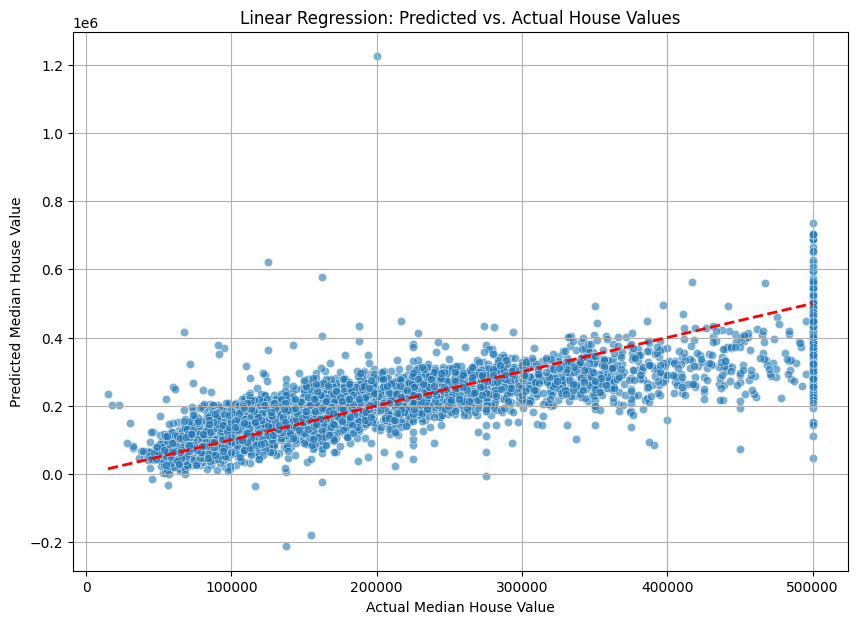

In [27]:
# Create a scatter plot of Predicted vs. Actual values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Linear Regression: Predicted vs. Actual House Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.grid(True)
plt.show()

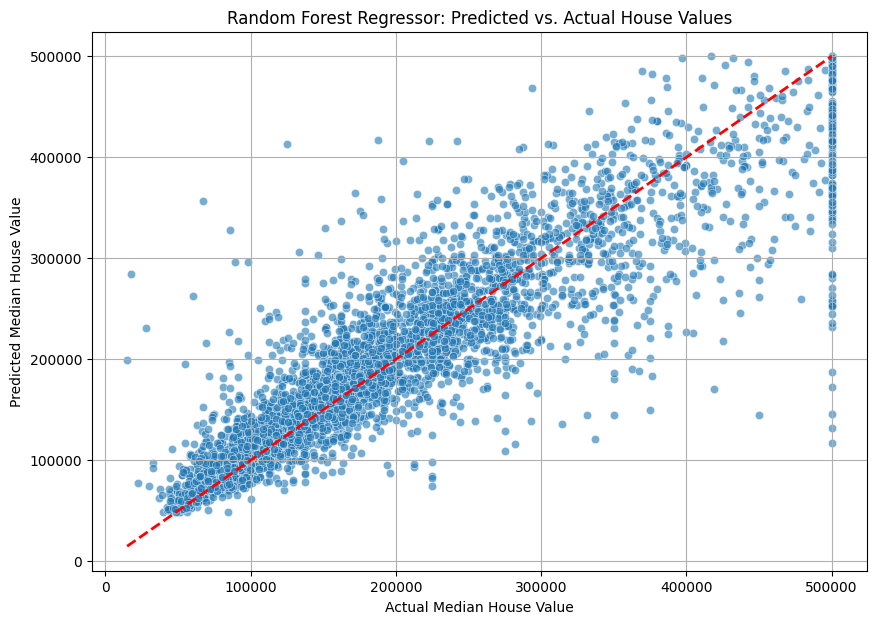

In [26]:
# Create a scatter plot of Predicted vs. Actual values for Random Forest
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Random Forest Regressor: Predicted vs. Actual House Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.grid(True)
plt.show()



Phase 6 — Prediction Demo

---


Create a small, friendly demo at the end of your notebook where a user can input feature values for a hypothetical block group (e.g., income, location, rooms) and see the model's predicted house value printed out.

In [34]:
#@title Predict Median House Value

# User Inputs (modify these values to test different scenarios)
user_longitude = -122.23 #@param {type:"number"}
user_latitude = 37.82 #@param {type:"number"}
user_housing_median_age = 40 #@param {type:"number"}
user_total_rooms = 946 #@param {type:"number"}
user_total_bedrooms = 375 #@param {type:"number"}
user_population = 700 #@param {type:"number"}
user_households = 352 #@param {type:"number"}
user_median_income = 700 #@param {type:"number"}
user_ocean_proximity = "NEAR BAY" #@param ["<1H OCEAN", "INLAND", "NEAR BAY", "NEAR OCEAN", "ISLAND"]

# --- Step 1: Create DataFrame from user inputs ---
# Include 'ocean_proximity' as a regular column for now
user_input_df = pd.DataFrame([[user_longitude, user_latitude, user_housing_median_age,
                               user_total_rooms, user_total_bedrooms, user_population,
                               user_households, user_median_income, user_ocean_proximity]],
                             columns=['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                                      'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity'])

# --- Step 2: Apply Feature Engineering (same as training data) ---
user_input_df['rooms_per_household'] = user_input_df['total_rooms'] / user_input_df['households']
user_input_df['bedrooms_per_room'] = user_input_df['total_bedrooms'] / user_input_df['total_rooms']
user_input_df['population_per_household'] = user_input_df['population'] / user_input_df['households']

# --- Step 3: Handle Categorical Feature (One-Hot Encoding) ---
ocean_proximity_cols_X_train = [col for col in X_train.columns if col.startswith('ocean_proximity_')]

# Apply one-hot encoding to the user's selected 'ocean_proximity'
user_ocean_proximity_encoded = pd.get_dummies(user_input_df['ocean_proximity'], prefix='ocean_proximity')

# Align this with ALL possible ocean_proximity columns from X_train
user_ocean_proximity_aligned = user_ocean_proximity_encoded.reindex(columns=ocean_proximity_cols_X_train, fill_value=False)

# --- Step 4: Scale Numerical Features (same as training data) ---
user_numerical_features = user_input_df[numerical_cols]

# Scale these numerical features using the pre-fitted scaler
user_numerical_scaled = scaler.transform(user_numerical_features)
user_numerical_scaled_df = pd.DataFrame(user_numerical_scaled, columns=numerical_cols, index=user_input_df.index)

# --- Step 5: Combine all prepared features and ensure correct order ---
final_user_input_temp = pd.concat([user_numerical_scaled_df, user_ocean_proximity_aligned], axis=1)

# Finally combined DataFrame to match the exact column order of X_train
final_user_input = final_user_input_temp.reindex(columns=X_train.columns, fill_value=0)

# Prediction using the Random Forest Model ---
predicted_value = random_forest_model.predict(final_user_input)

print(f"\nBased on your inputs, the predicted median house value is: ${predicted_value[0]:,.2f}")


Based on your inputs, the predicted median house value is: $481,067.71
